<a href="https://colab.research.google.com/github/fuadryder/ProjectPortofolioDataAnalyst/blob/main/Student_performance_final_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Get data

In [2]:
df = pd.read_csv('/content/student_performance_finalscore.csv')
df.head(5)

,Student_ID,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,STU00001,17,Female,8.20,80.0,7.3,2.3,3.2,3.07,No,Online,Average,Average,Yes,3,High,1.8,87.10
1,STU00002,22,Male,4.07,69.2,7.9,3.6,0.5,2.66,Yes,Offline,Average,Good,No,2,Middle,1.0,92.03
2,STU00003,23,Female,5.07,74.2,6.7,2.6,4.7,3.27,No,Hybrid,Average,Good,No,1,Middle,4.2,95.37
3,STU00004,22,Female,5.82,82.5,3.7,3.3,2.3,2.87,No,Offline,Average,Excellent,No,0,Middle,3.6,90.73
4,STU00005,21,Male,3.42,90.8,7.4,7.0,3.1,2.82,Yes,Offline,Average,Good,No,2,Middle,4.5,74.71


#Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  8000 non-null   object 
 1   Age                         8000 non-null   int64  
 2   Gender                      8000 non-null   object 
 3   Hours_Studied               8000 non-null   float64
 4   Attendance                  8000 non-null   float64
 5   Sleep_Hours                 8000 non-null   float64
 6   Stress_Level                8000 non-null   float64
 7   Screen_Time                 8000 non-null   float64
 8   Previous_GPA                8000 non-null   float64
 9   Part_Time_Job               8000 non-null   object 
 10  Study_Method                8000 non-null   object 
 11  Diet_Quality                8000 non-null   object 
 12  Internet_Quality            8000 non-null   object 
 13  Extracurricular             8000 

In [4]:
df.describe().round(2)

,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,20.49,4.98,79.93,6.99,5.01,4.02,2.99,1.70,4.49,83.21
std,2.29,1.95,9.66,1.19,1.94,1.48,0.49,1.11,1.69,12.76
min,17.00,0.02,43.30,3.00,1.00,0.50,1.50,0.00,1.00,22.81
25%,18.00,3.68,73.40,6.20,3.70,3.00,2.67,1.00,3.30,75.51
50%,20.50,4.98,80.10,7.00,5.00,4.00,2.99,2.00,4.40,86.51
75%,22.00,6.31,86.60,7.80,6.30,5.00,3.33,2.00,5.60,93.08
max,24.00,12.00,100.00,10.00,10.00,9.60,6.70,5.00,10.00,99.98


In [5]:
print('Duplicate row: ' + str(df.duplicated().sum()))

Duplicate row: 0


In [6]:
print("Missing value : " + str(df.isnull().sum().sum()))

Missing value : 0


#Target Varaible distribution

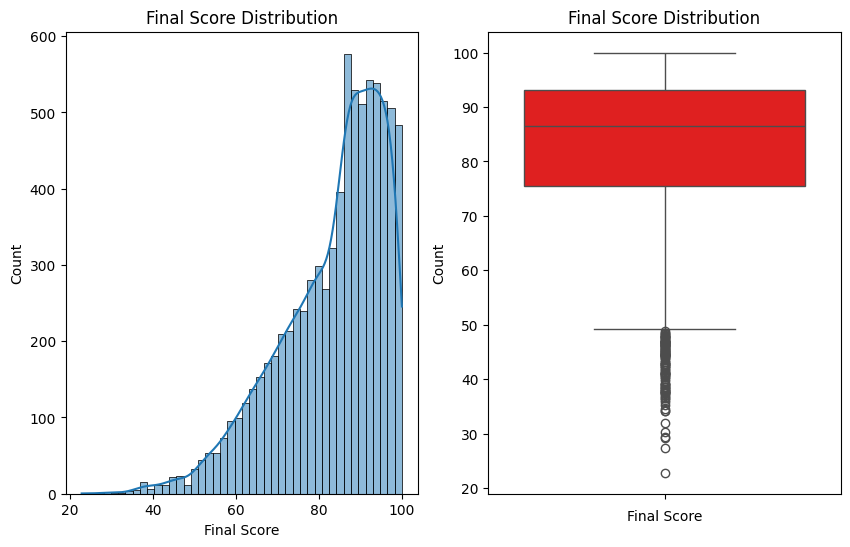

In [7]:
fig, ax = plt.subplots(1,2, figsize = (10,6))

#histplot
sns.histplot(df['Final_Score'], kde = True, ax = ax[0])
ax[0].set_title('Final Score Distribution')
ax[0].set_xlabel('Final Score')
ax[0].set_ylabel('Count')

#boxplot
sns.boxplot(df['Final_Score'], ax = ax[1], color= 'red')
ax[1].set_title('Final Score Distribution')
ax[1].set_xlabel('Final Score')
ax[1].set_ylabel('Count')

plt.show()

# Feature Distribution

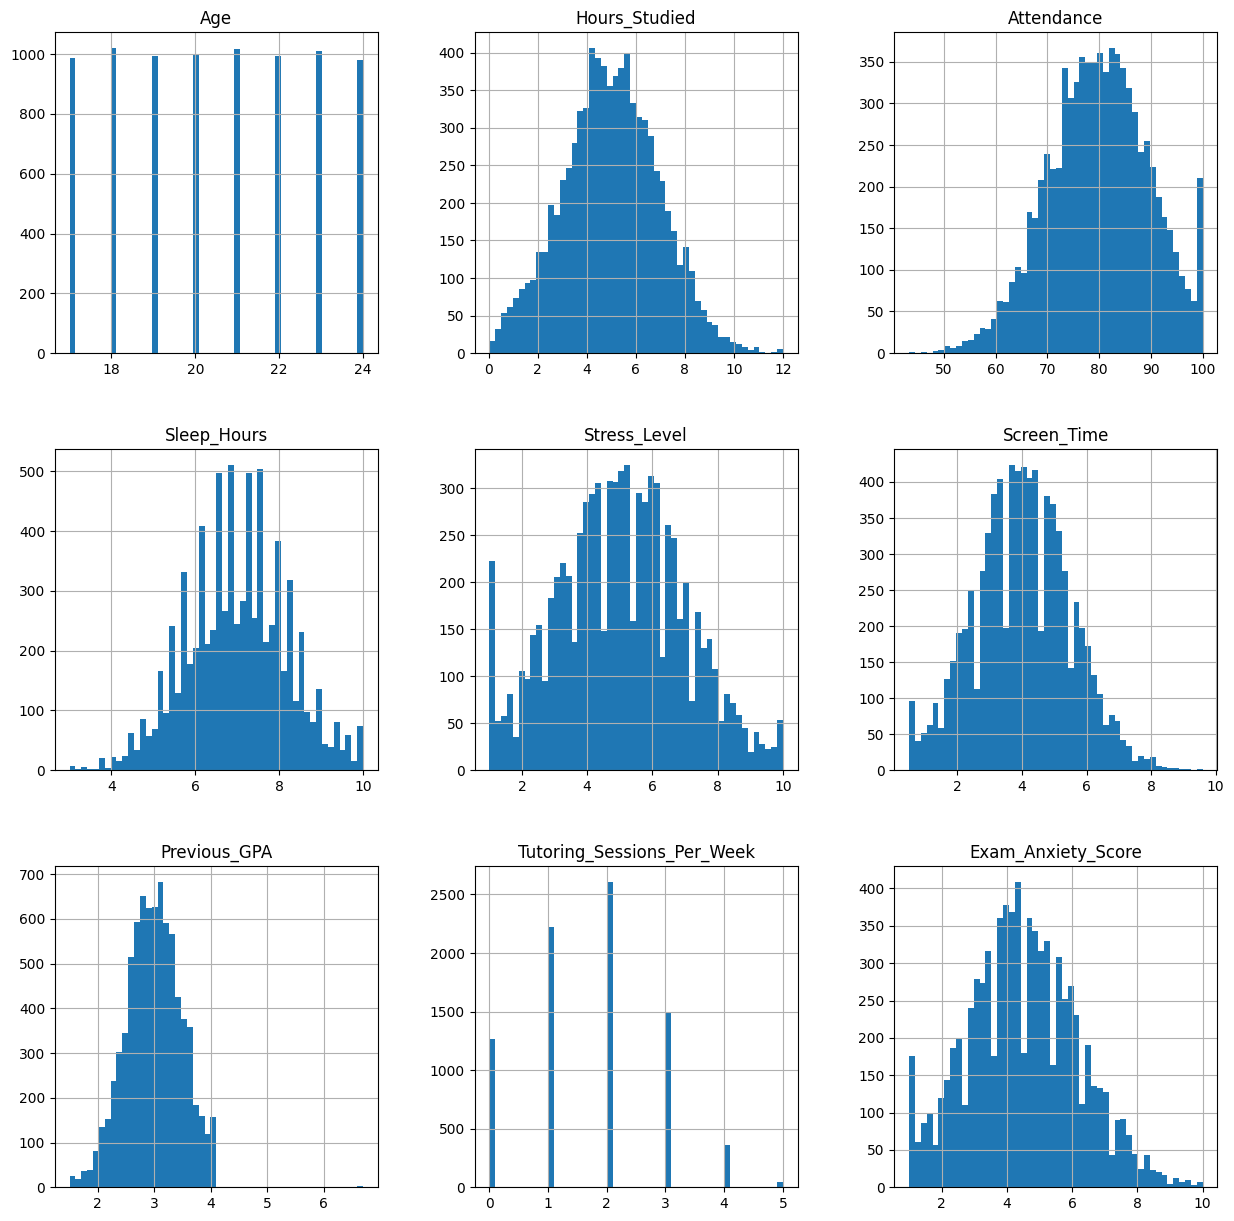

In [8]:
#numerical feature distribution
df.drop('Final_Score', axis = 1).hist(figsize=(15,15), bins = 50)
plt.show()

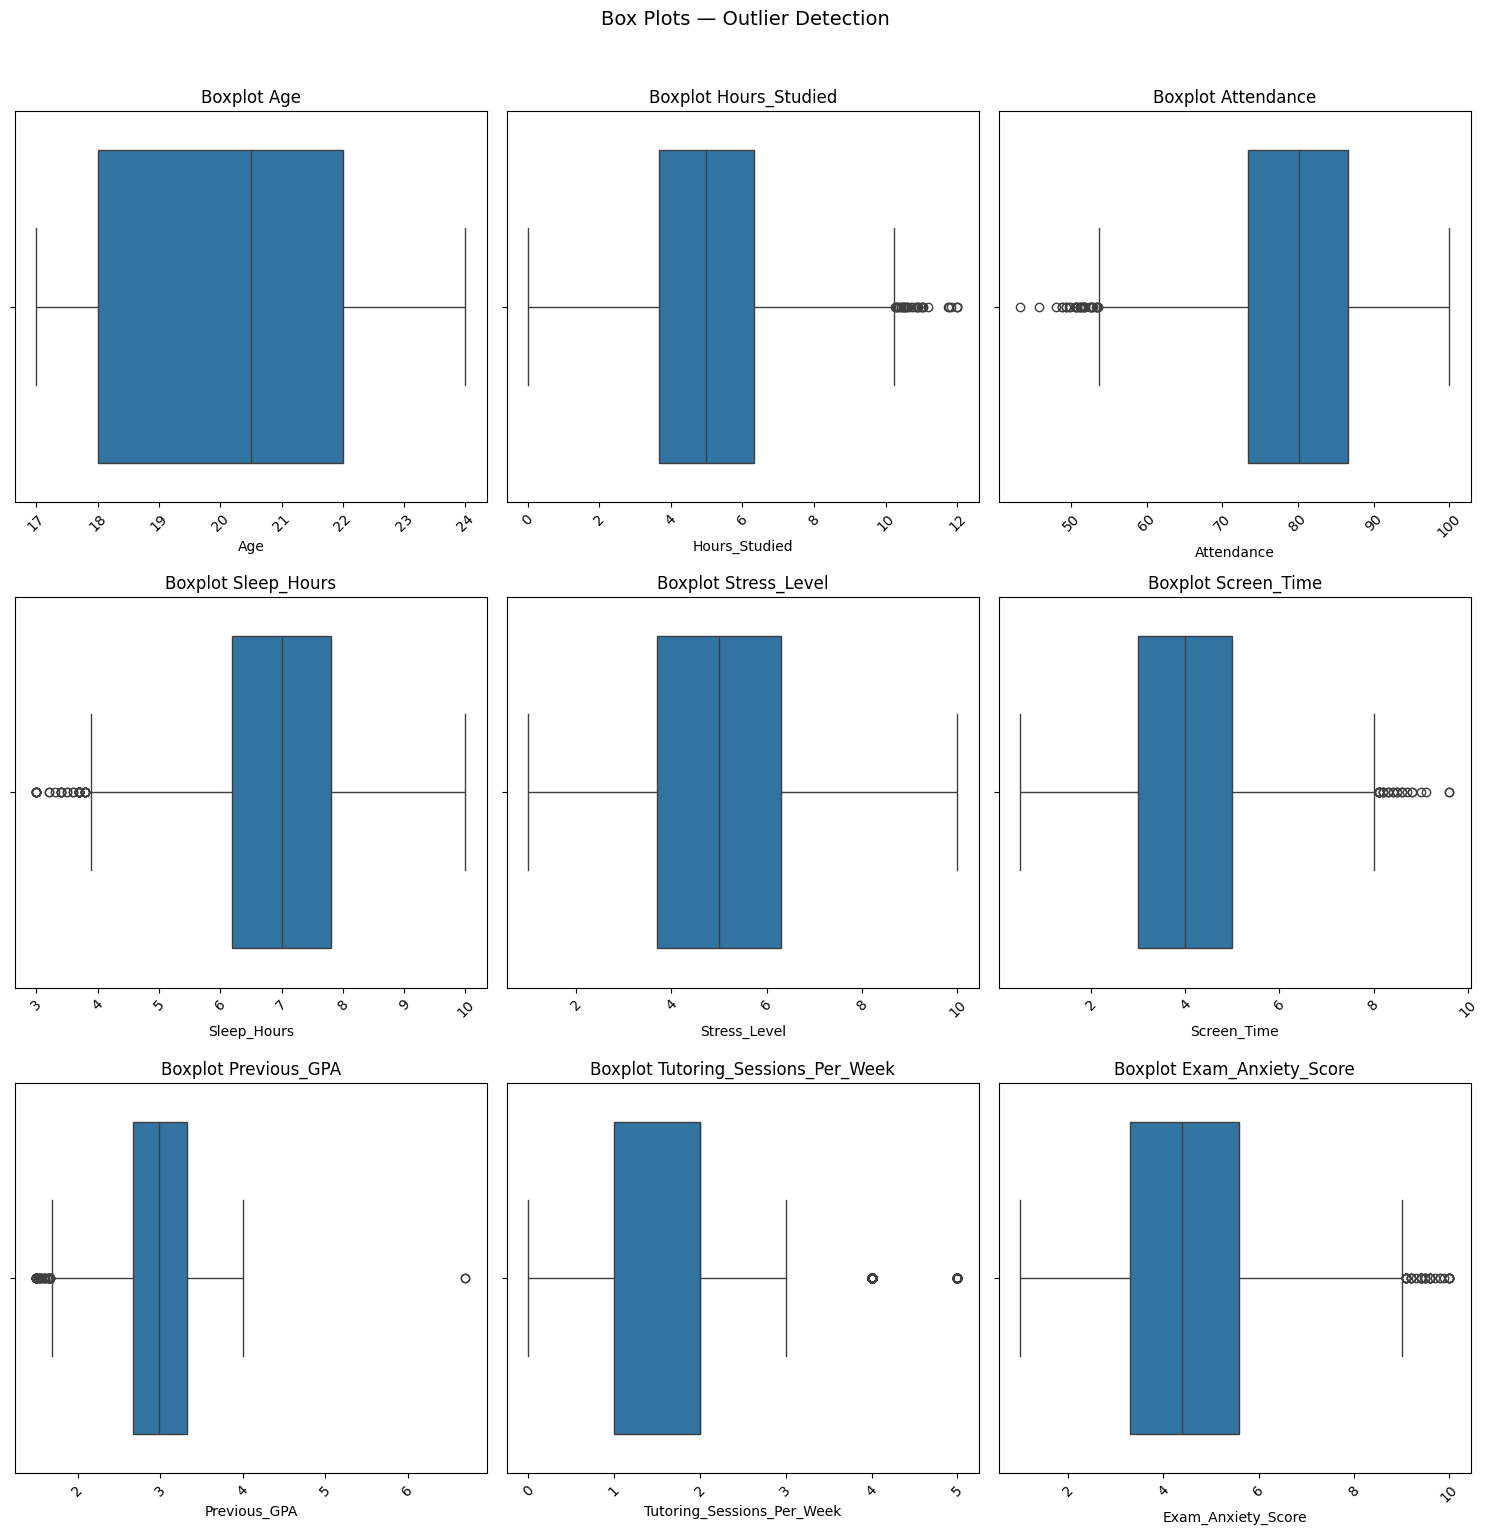

In [9]:
num_cols = [col for col in df.drop('Final_Score', axis = 1) if df[col].dtype != 'object']

# boxplot
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Boxplot {col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle("Box Plots — Outlier Detection", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

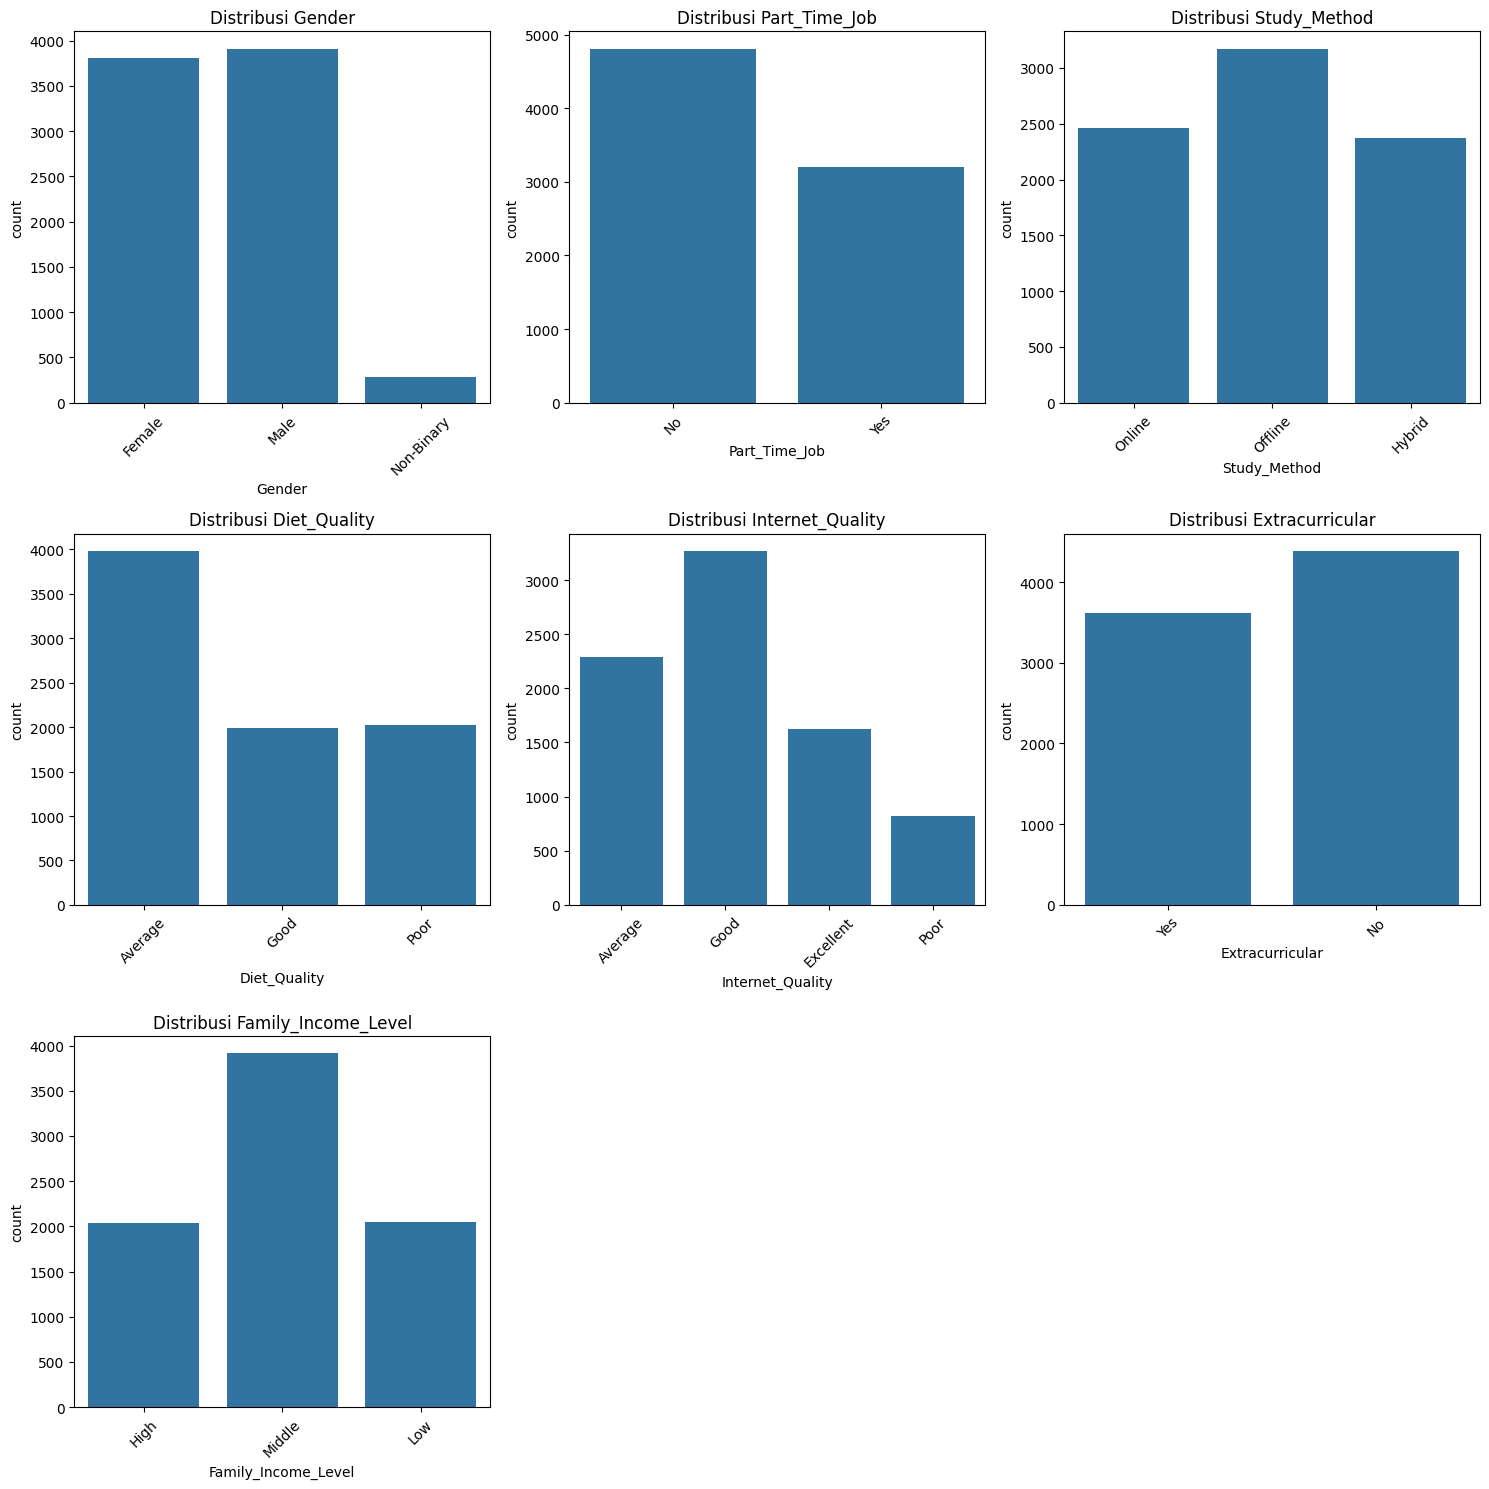

In [10]:
# object feature distribution
obj_cols = [col for col in df.drop('Student_ID', axis=1) if df[col].dtype == 'object']

# making columns for plot
n_rows, n_cols = 3, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))

# flatten axes
axes = axes.flatten()

# loop for each obj column
for i, col in enumerate(obj_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Distribusi {col}")
    axes[i].tick_params(axis='x', rotation=45)


for j in range(len(obj_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

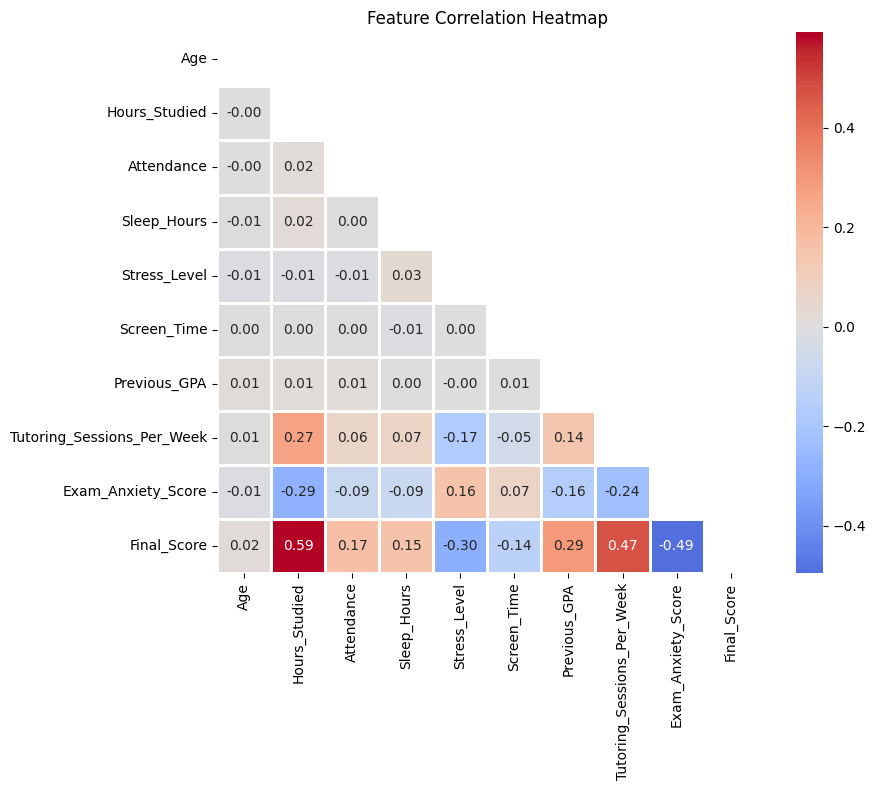

In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only= True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [12]:
correlation = df.corr(numeric_only= True)
correlation['Final_Score'].sort_values(ascending=False)

,Final_Score
Final_Score,1.000000
Hours_Studied,0.591355
Tutoring_Sessions_Per_Week,0.471524
Previous_GPA,0.291002
Attendance,0.168615
Sleep_Hours,0.151673
Age,0.017103
Screen_Time,-0.135252
Stress_Level,-0.296634
Exam_Anxiety_Score,-0.494940


<Axes: xlabel='Final_Score', ylabel='Hours_Studied'>

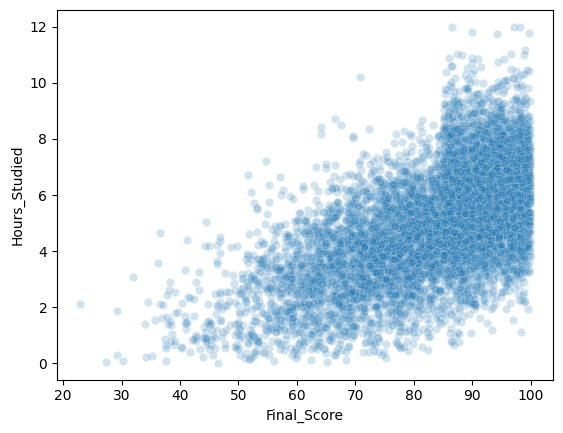

In [13]:

sns.scatterplot(data = df, x = 'Final_Score', y = 'Hours_Studied', alpha = 0.2)
plt.title('Final Score vs. Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.show()

<Axes: xlabel='Final_Score', ylabel='Tutoring_Sessions_Per_Week'>

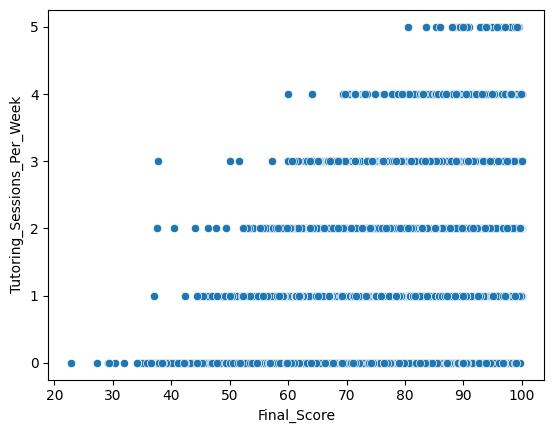

In [14]:
sns.scatterplot(data = df, x = 'Final_Score', y = 'Tutoring_Sessions_Per_Week')

In [15]:
#label encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df = df.drop('Student_ID', axis=1)
for col in df.columns :
  if df[col].dtype == 'object':
    df[col]= le.fit_transform(df[col])
df.head()


,Age,Gender,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Part_Time_Job,Study_Method,Diet_Quality,Internet_Quality,Extracurricular,Tutoring_Sessions_Per_Week,Family_Income_Level,Exam_Anxiety_Score,Final_Score
0,17,0,8.20,80.0,7.3,2.3,3.2,3.07,0,2,0,0,1,3,0,1.8,87.10
1,22,1,4.07,69.2,7.9,3.6,0.5,2.66,1,1,0,2,0,2,2,1.0,92.03
2,23,0,5.07,74.2,6.7,2.6,4.7,3.27,0,0,0,2,0,1,2,4.2,95.37
3,22,0,5.82,82.5,3.7,3.3,2.3,2.87,0,1,0,1,0,0,2,3.6,90.73
4,21,1,3.42,90.8,7.4,7.0,3.1,2.82,1,1,0,2,0,2,2,4.5,74.71


In [16]:
x = df.drop('Final_Score', axis=1)
y = df['Final_Score']

In [17]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

# Build model

In [19]:
# import all model and metric
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Random forest

In [20]:
#random forest
rf = RandomForestRegressor()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

In [21]:
#metric
print ('MAE:', mean_absolute_error(y_test, y_pred_rf))
print ('MSE:', mean_squared_error(y_test, y_pred_rf))
print ('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print ('R2 Score:', r2_score(y_test, y_pred_rf))
#

MAE: 5.4087601875
MSE: 48.31551267979375
RMSE: 6.95093610097185
R2 Score: 0.7070574057710913


In [22]:
# random forest model with hyperparamter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [2, 4]
}

grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5, scoring='neg_mean_squared_error',
                           n_jobs = -1
                           )
grid_search.fit(x_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Score (MSE):", -grid_search.best_score_)
y_pred_best = best_model.predict(x_test)
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("R2:", r2_score(y_test, y_pred_best))


Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Score (MSE): 49.277983145023285
MAE: 5.418917374866594
MSE: 48.56409128299372
R2: 0.7055502446782597


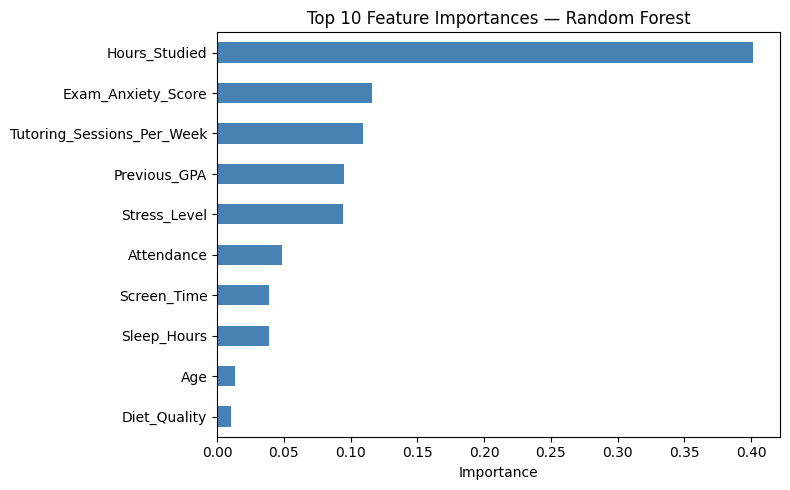

In [23]:
rf_importances = pd.Series(best_model.feature_importances_, index=x_train.columns).sort_values(ascending=True)
rf_importances.tail(10).plot(kind="barh", color="steelblue", figsize=(8, 5))
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# 2. Linear Regression

In [24]:
# linear regression
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)
y_pred_lr = lr.predict(x_test_scaled)

# metrics
print ('MAE:', mean_absolute_error(y_test, y_pred_lr))
print ('MSE:', mean_squared_error(y_test, y_pred_lr))
print ('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print ('R2 Score:', r2_score(y_test, y_pred_lr))


MAE: 5.626135525646757
MSE: 51.14462659241977
RMSE: 7.151547146766199
R2 Score: 0.6899041578188996


#3. Decission Tree

In [25]:
#Decision Tree
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)

#metrics
print ('MAE:', mean_absolute_error(y_test, y_pred_dt))
print ('MSE:', mean_squared_error(y_test, y_pred_best))
print ('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print ('R2 Score:', r2_score(y_test, y_pred_dt))

MAE: 7.7562375
MSE: 48.56409128299372
RMSE: 10.148964916433597
R2 Score: 0.3754899474946153


In [26]:
# decision tree hyperparameter tuning using random search
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth': randint(1, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10)
}

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

random_search.fit(x_train, y_train)

best_params = random_search.best_params_
best_model = random_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Score (MSE):", -random_search.best_score_)
y_pred_best = best_model.predict(x_test)
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("R2:", r2_score(y_test, y_pred_best))


Best Parameters: {'max_depth': 7, 'min_samples_leaf': 9, 'min_samples_split': 6}
Best Score (MSE): 72.2083204732031
MAE: 6.46123568219923
MSE: 71.44396899074215
R2: 0.566826874903254


In [27]:
#dtree tuned
dt_tuned = random_search.best_estimator_
y_pred_best = dt_tuned.predict(x_test)

#metrics
print ('MAE:', mean_absolute_error(y_test, y_pred_best))
print ('MSE:', mean_squared_error(y_test, y_pred_best))
print ('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_best)))
print ('R2 Score:', r2_score(y_test, y_pred_best))

MAE: 6.46123568219923
MSE: 71.44396899074215
RMSE: 8.452453430261663
R2 Score: 0.566826874903254


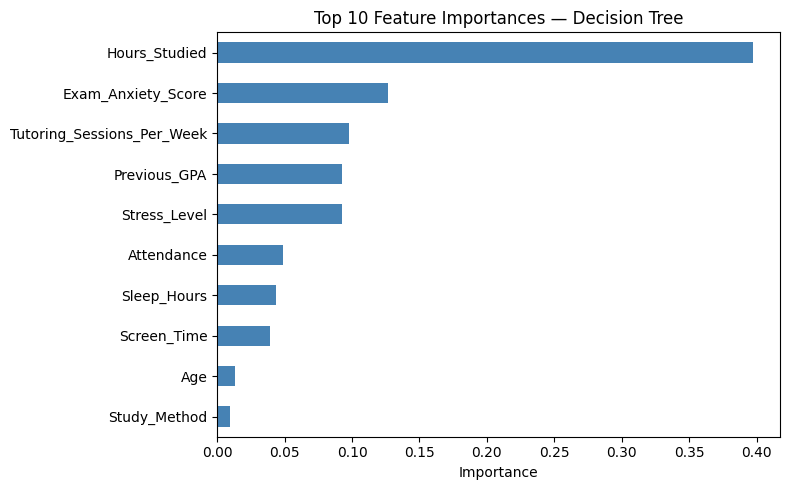

In [28]:
feat_imp = pd.Series(dt.feature_importances_, index=x_train.columns).sort_values(ascending=True)
feat_imp.tail(10).plot(kind="barh", color="steelblue", figsize=(8, 5))
plt.title("Top 10 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#4. SVR

In [29]:
# SVR
svr = SVR()
svr.fit(x_train_scaled, y_train)
y_pred_svr = svr.predict(x_test_scaled)

#metrics
print ('MAE:', mean_absolute_error(y_test, y_pred_svr))
print ('MSE:', mean_squared_error(y_test, y_pred_svr))
print ('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_svr)))
print ('R2 Score:', r2_score(y_test, y_pred_svr))

MAE: 5.2548685229034025
MSE: 45.96119340682813
RMSE: 6.779468519495325
R2 Score: 0.7213319183905983


#5. KNN

In [30]:
# KNN
knn = KNeighborsRegressor(
    n_neighbors=10,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None
)
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_test_scaled)

# metrics
print ('MAE:', mean_absolute_error(y_test, y_pred_knn))
print ('MSE:', mean_squared_error(y_test, y_pred_knn))
print ('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print ('R2 Score:', r2_score(y_test, y_pred_knn))

MAE: 6.12974875
MSE: 62.7570644325
RMSE: 7.921935649353635
R2 Score: 0.6194965914387187


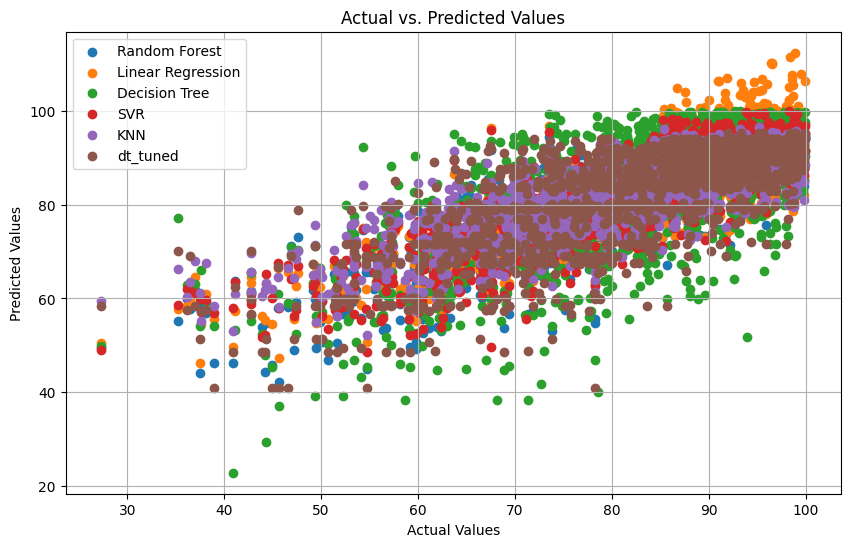

In [31]:
predictions = {
    'Random Forest': y_pred_rf,
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'SVR': y_pred_svr,
    'KNN': y_pred_knn,
    'dt_tuned': y_pred_best
}

plt.figure(figsize=(10, 6))
for model_name, predictions in predictions.items():
    plt.scatter(y_test, predictions, label=model_name)

plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

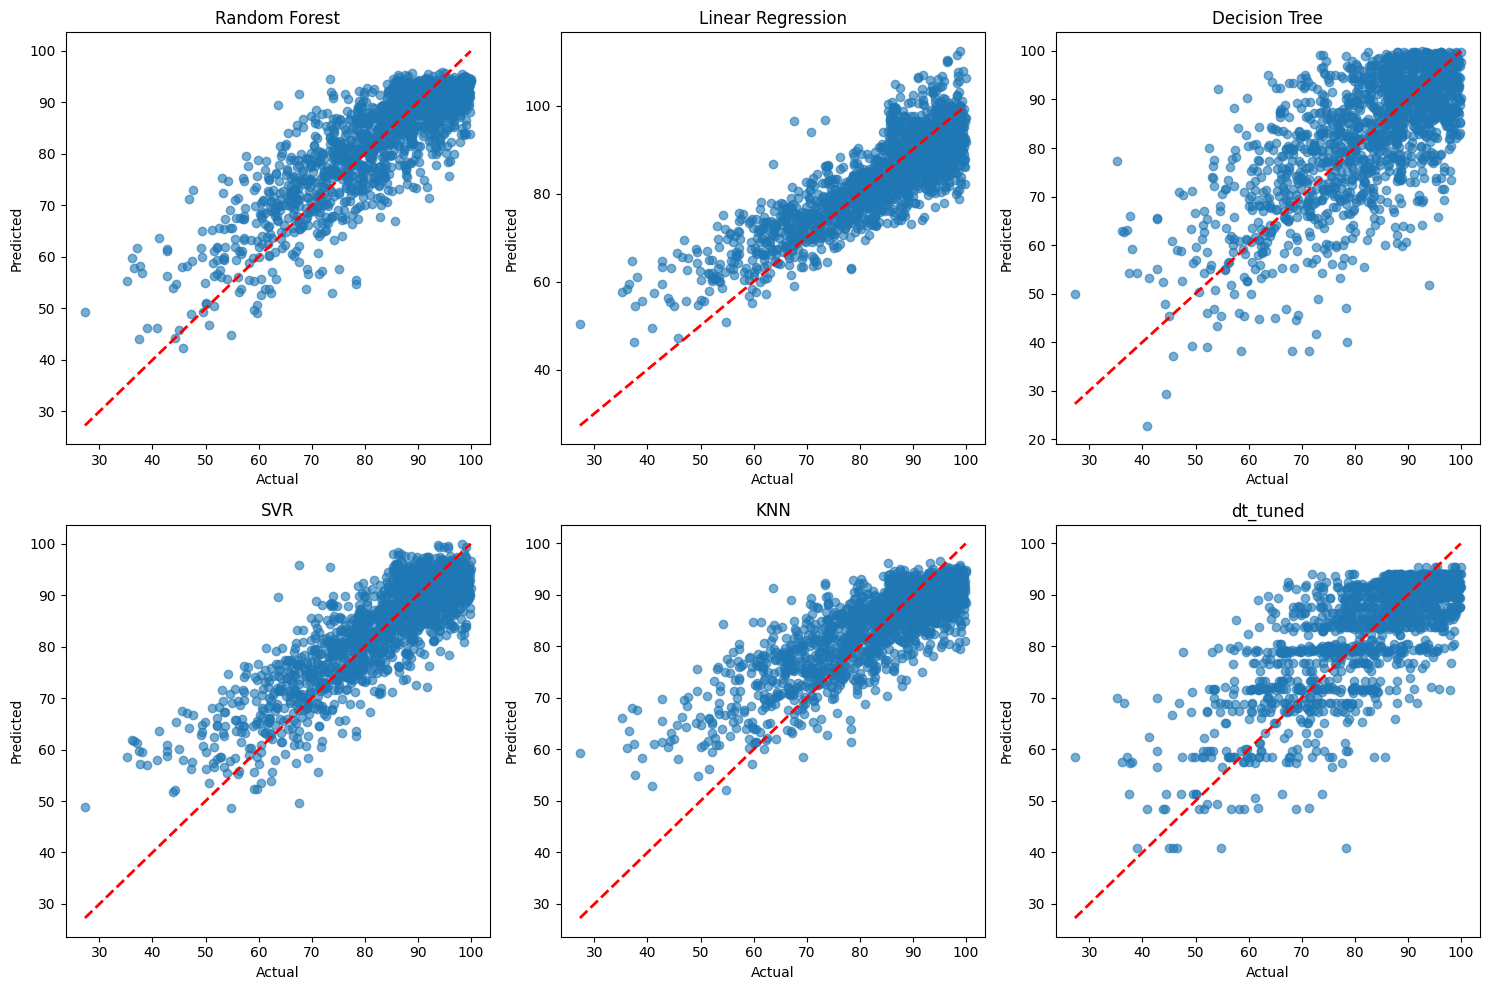

In [32]:
predictions = {
    'Random Forest': y_pred_rf,
    'Linear Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'SVR': y_pred_svr,
    'KNN': y_pred_knn,
    'dt_tuned': y_pred_best
}

fig, axes = plt.subplots(2, 3, figsize=(15,10))  # 2 baris, 3 kolom
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    axes[i].scatter(y_test, y_pred, alpha=0.6)
    axes[i].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()],
                 'r--', lw=2)  # garis ideal y=x
    axes[i].set_title(name)
    axes[i].set_xlabel("Actual")
    axes[i].set_ylabel("Predicted")

for j in range(len(predictions), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

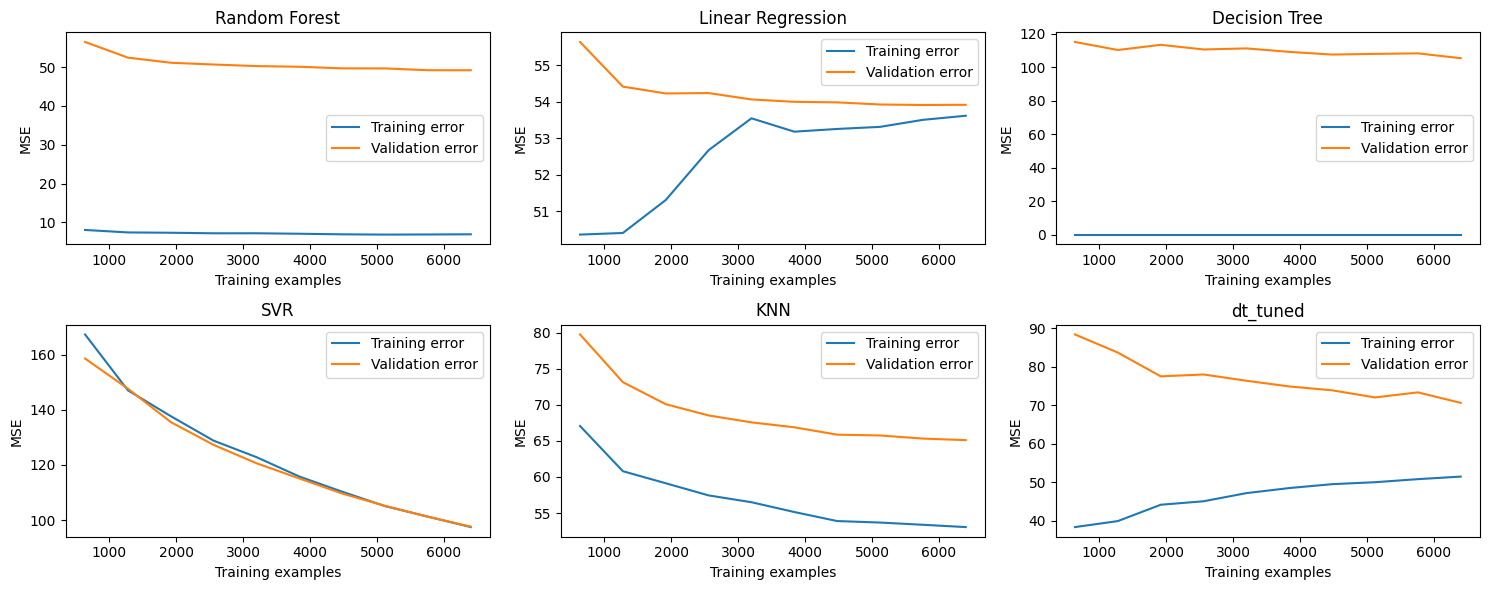

In [33]:
from sklearn.model_selection import learning_curve

models = {
    'Random Forest': rf,
    'Linear Regression': lr,
    'Decision Tree': dt,
    'SVR': svr,
    'KNN': knn,
    'dt_tuned': dt_tuned
}

#plot learning curve for each models
fig, axes = plt.subplots(2, 3, figsize=(15,6))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
  train_sizes, train_scores, val_scores = learning_curve(
      model,
      x, y,
      cv=5,
      scoring='neg_mean_squared_error',
      n_jobs=-1,
      train_sizes=np.linspace(0.1, 1.0, 10)
  )
  train_scores_mean = -train_scores.mean(axis=1)
  val_scores_mean = -val_scores.mean(axis=1)
  axes[i].plot(train_sizes, train_scores_mean, label='Training error')
  axes[i].plot(train_sizes, val_scores_mean, label='Validation error')
  axes[i].set_title(name)
  axes[i].set_xlabel('Training examples')
  axes[i].set_ylabel('MSE')
  axes[i].legend()

for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Final Summary

In [34]:
results = []

models = {
    "Linear Regression" : y_pred_lr,
    "Random Forest" : y_pred_rf,
    "Decision Tree" : y_pred_dt,
    "SVR" : y_pred_svr,
    "KNN" : y_pred_knn,
    'dt_tuned': y_pred_best
}

for name, y_pred in models.items():
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  results.append({
      'Model' : name,
      'MAE' : mae,
      'MSE' : mse,
      'RMSE' : rmse,
      'R2' : r2
  })

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,5.626136,51.144627,7.151547,0.689904
1,Random Forest,5.408760,48.315513,6.950936,0.707057
2,Decision Tree,7.756238,103.001489,10.148965,0.375490
3,SVR,5.254869,45.961193,6.779469,0.721332
4,KNN,6.129749,62.757064,7.921936,0.619497
5,dt_tuned,6.461236,71.443969,8.452453,0.566827


Among the six regression models tested, Support Vector Regression (SVR) achieved the best overall performance, with the lowest error values (MAE, MSE, RMSE) and the highest coefficient of determination (R² ≈ 0.72). This indicates that SVR was the most effective at capturing the underlying patterns in the dataset and generalizing well to unseen data.

Random Forest also performed strongly (R² ≈ 0.70), making it a reliable alternative with good stability and interpretability through feature importance. Linear Regression provided a solid baseline (R² ≈ 0.69), but its linear nature limited its accuracy compared to more flexible models.

In contrast, the Decision Tree (default) suffered from severe overfitting, with very low training error but poor validation performance (R² ≈ 0.35). The tuned Decision Tree showed improvement (R² ≈ 0.57), but still lagged behind SVR and Random Forest. KNN Regression delivered moderate results (R² ≈ 0.62), sensitive to parameter choices and scaling.



1.   ✅ Final Takeaway
* Best model: SVR (highest accuracy and generalization).

* Strong alternative: Random Forest (stable and interpretable).

* Baseline: Linear Regression (simple but limited).

* Weak performers: Decision Tree (overfitting) and KNN (average, requires tuning).




